# IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

from sklearn.cluster import (
    KMeans,
    DBSCAN,
    AgglomerativeClustering
)

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score
)

from scipy.cluster.hierarchy import (
    linkage,
    dendrogram
)

In [2]:
df = pd.read_pickle("G:/Mohanraj D_OFFICIAL/GUVI (Data Analyst)/Mini-Projects/PatrolIQ/engineered_chicago_crime_data.pkl")
df.head()

,Date,Primary Type,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,Year,...,Hour,Is_Weekend,Season,Lat_bin,Lon_bin,Crime_Severity_Score,Location_Desc_freq,Primary Type_freq,Latitude_Norm,Longitude_Norm
0,2016-12-31 23:59:00,30,3,0,0,1651,16,41,76,2016,...,23,1,3,"(41.753, 42.023]","(-87.941, -87.733]",1.0,0.000122,0.216753,1.470472,-3.629450
1,2016-12-31 23:58:00,2,135,0,0,522,5,34,49,2016,...,23,1,3,"(41.482, 41.753]","(-87.733, -87.525]",3.0,0.163276,0.178889,-1.663659,0.753301
2,2016-12-31 23:55:00,16,135,1,0,1932,19,32,6,2016,...,23,1,3,"(41.753, 42.023]","(-87.733, -87.525]",1.0,0.163276,0.001666,1.042028,0.117016
3,2016-12-31 23:55:00,2,99,0,1,111,1,42,32,2016,...,23,1,3,"(41.753, 42.023]","(-87.733, -87.525]",3.0,0.003961,0.178889,0.497632,0.727418
4,2016-12-31 23:54:00,6,135,0,1,623,6,6,69,2016,...,23,1,3,"(41.482, 41.753]","(-87.733, -87.525]",2.0,0.163276,0.111719,-0.964830,0.817709


In [3]:
df.head()

,Date,Primary Type,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,Year,...,Hour,Is_Weekend,Season,Lat_bin,Lon_bin,Crime_Severity_Score,Location_Desc_freq,Primary Type_freq,Latitude_Norm,Longitude_Norm
0,2016-12-31 23:59:00,30,3,0,0,1651,16,41,76,2016,...,23,1,3,"(41.753, 42.023]","(-87.941, -87.733]",1.0,0.000122,0.216753,1.470472,-3.629450
1,2016-12-31 23:58:00,2,135,0,0,522,5,34,49,2016,...,23,1,3,"(41.482, 41.753]","(-87.733, -87.525]",3.0,0.163276,0.178889,-1.663659,0.753301
2,2016-12-31 23:55:00,16,135,1,0,1932,19,32,6,2016,...,23,1,3,"(41.753, 42.023]","(-87.733, -87.525]",1.0,0.163276,0.001666,1.042028,0.117016
3,2016-12-31 23:55:00,2,99,0,1,111,1,42,32,2016,...,23,1,3,"(41.753, 42.023]","(-87.733, -87.525]",3.0,0.003961,0.178889,0.497632,0.727418
4,2016-12-31 23:54:00,6,135,0,1,623,6,6,69,2016,...,23,1,3,"(41.482, 41.753]","(-87.733, -87.525]",2.0,0.163276,0.111719,-0.964830,0.817709


In [4]:
df.tail()

,Date,Primary Type,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,Year,...,Hour,Is_Weekend,Season,Lat_bin,Lon_bin,Crime_Severity_Score,Location_Desc_freq,Primary Type_freq,Latitude_Norm,Longitude_Norm
2997475,2008-01-01,30,162,0,0,2531,25,29,25,2008,...,0,0,3,"(41.753, 42.023]","(-87.941, -87.733]",1.0,0.240459,0.216753,0.774413,-1.454161
2997476,2008-01-01,23,135,0,0,2123,2,4,39,2008,...,0,0,3,"(41.753, 42.023]","(-87.733, -87.525]",1.0,0.163276,0.060864,-0.292613,1.136171
2997477,2008-01-01,30,135,0,0,823,8,15,66,2008,...,0,0,3,"(41.753, 42.023]","(-87.733, -87.525]",1.0,0.163276,0.216753,-0.681098,-0.461506
2997478,2008-01-01,30,135,0,0,434,4,10,51,2008,...,0,0,3,"(41.482, 41.753]","(-87.733, -87.525]",1.0,0.163276,0.216753,-1.492636,1.717740
2997479,2008-01-01,23,135,0,0,1121,11,27,23,2008,...,0,0,3,"(41.753, 42.023]","(-87.733, -87.525]",1.0,0.163276,0.060864,0.614482,-0.611091


# SELECT GEOGRAPHIC FEATURES

In [5]:
geo_features = [
    'Latitude',
    'Longitude',
    'Hour',
    'Month',
    'Crime_Severity_Score'
]

In [6]:
# CREATE GEOGRAPHIC DATASET

geo_df = df[geo_features].copy()

geo_df.dropna(inplace=True)

In [7]:
# SCALE GEOGRAPHIC FEATURES

scaler_geo = StandardScaler()

X_geo_scaled = scaler_geo.fit_transform(geo_df)

In [8]:
# ELBOW METHOD

inertia = []

K = range(2, 11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X_geo_scaled)

    inertia.append(kmeans.inertia_)

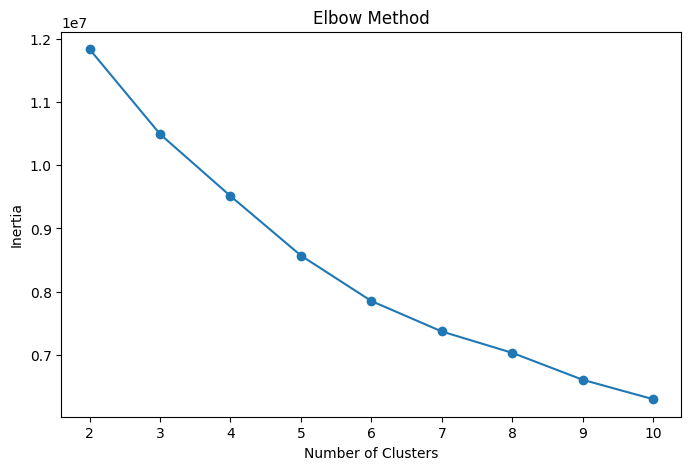

In [9]:
# PLOT ELBOW CURVE

plt.figure(figsize=(8,5))

plt.plot(
    K,
    inertia,
    marker='o'
)

plt.xlabel('Number of Clusters')

plt.ylabel('Inertia')

plt.title('Elbow Method')

plt.show()

In [10]:
# FINAL KMEANS MODEL

kmeans_geo = KMeans(
    n_clusters=7,
    random_state=42
)

geo_df['Geo_Cluster'] = (
    kmeans_geo.fit_predict(
        X_geo_scaled
    )
)

In [11]:
geo_silhouette = silhouette_score(

    X_geo_scaled,

    geo_df['Geo_Cluster'],

    sample_size=10000,

    random_state=42
)

print(
    "Silhouette Score :",
    geo_silhouette
)

Silhouette Score : 0.17597788603022838


In [12]:
# DAVIES-BOULDIN SCORE

geo_db_score = davies_bouldin_score(
    X_geo_scaled,
    geo_df['Geo_Cluster']
)

print("Davies-Bouldin Score :", geo_db_score)

Davies-Bouldin Score : 1.4795657769770234


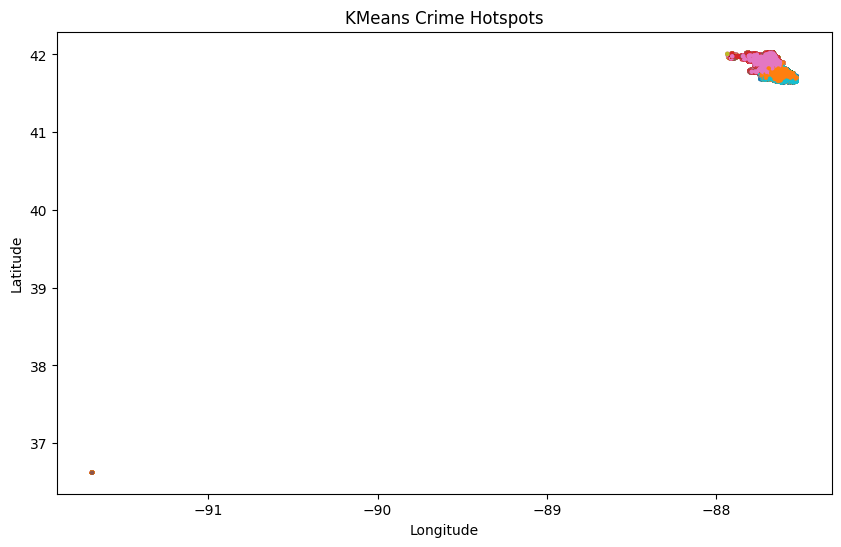

In [13]:
# VISUALIZE KMEANS HOTSPOTS

plt.figure(figsize=(10,6))

plt.scatter(

    geo_df['Longitude'],

    geo_df['Latitude'],

    c=geo_df['Geo_Cluster'],

    cmap='tab10',

    s=5
)

plt.xlabel('Longitude')

plt.ylabel('Latitude')

plt.title('KMeans Crime Hotspots')

plt.show()

In [14]:
# Sample Data for Efficiency
geo_sample = geo_df.sample(
    50000,
    random_state=42
)

In [15]:
# Scale Sample

X_geo_sample = scaler_geo.fit_transform(

    geo_sample[geo_features]
)

In [16]:
# DBSCAN MODEL

dbscan_geo = DBSCAN(
    eps=0.5,
    min_samples=10
)

geo_sample['DBSCAN_Cluster'] = (

    dbscan_geo.fit_predict(
        X_geo_sample
    )
)

In [17]:
# Check Clusters

geo_sample['DBSCAN_Cluster'].value_counts()

DBSCAN_Cluster
 0     19784
 2     14469
 1     12325
 3      1870
-1      1325
 4        91
 5        62
 7        19
 6        12
 12       10
 11       10
 8         8
 10        8
 9         7
Name: count, dtype: int64

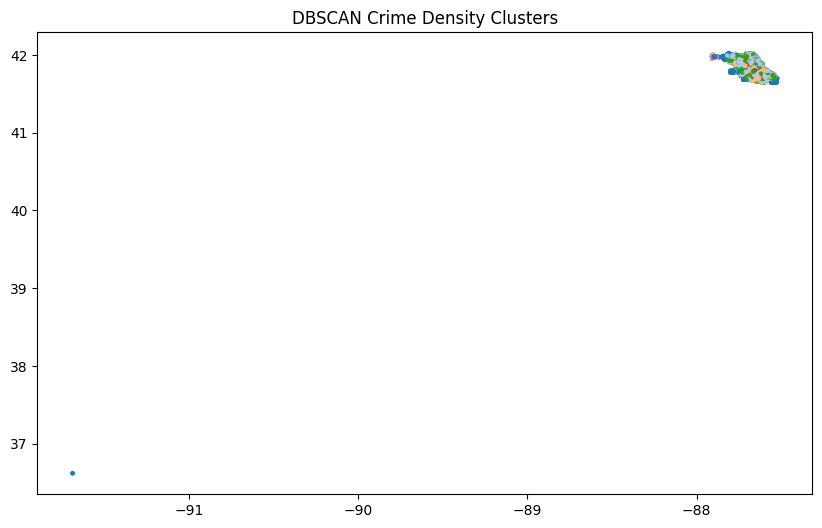

In [18]:
# Visualize DBSCAN

plt.figure(figsize=(10,6))

plt.scatter(

    geo_sample['Longitude'],

    geo_sample['Latitude'],

    c=geo_sample['DBSCAN_Cluster'],

    cmap='tab20',

    s=5
)

plt.title('DBSCAN Crime Density Clusters')

plt.show()

In [19]:
# HIERARCHICAL CLUSTERING

hier_sample = geo_df.sample(
    5000,
    random_state=42
)

In [20]:
X_hier = scaler_geo.fit_transform(

    hier_sample[geo_features]
)

In [21]:
# Linkage Matrix

linked = linkage(
    X_hier,
    method='ward'
)

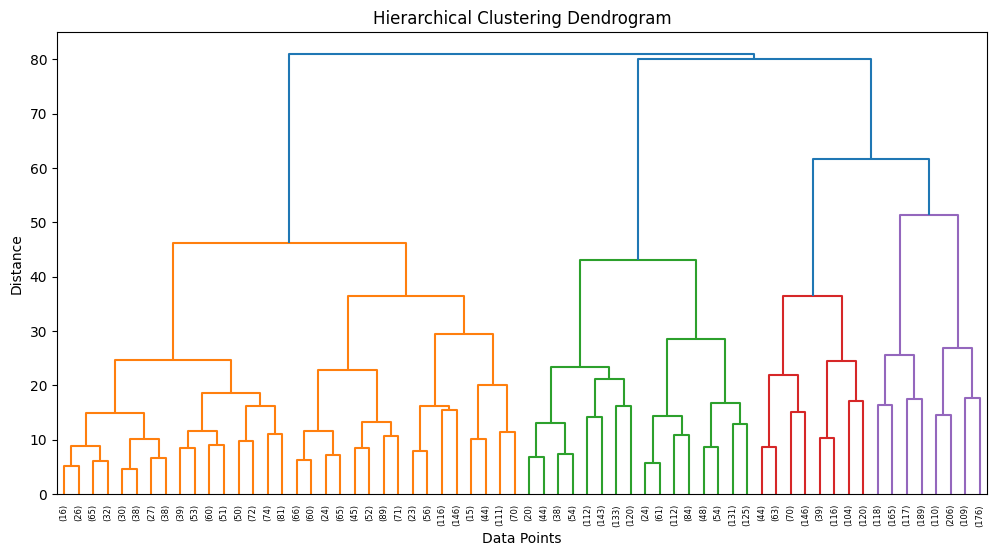

In [22]:
# Plot Dendrogram

plt.figure(figsize=(12,6))

dendrogram(
    linked,
    truncate_mode='level',
    p=5
)

plt.title(
    'Hierarchical Clustering Dendrogram'
)

plt.xlabel('Data Points')

plt.ylabel('Distance')

plt.show()

In [23]:
# Train Hierarchical Model

hc_geo = AgglomerativeClustering(
    n_clusters=7,
    linkage='ward'
)

hier_sample['HC_Cluster'] = (

    hc_geo.fit_predict(
        X_hier
    )
)

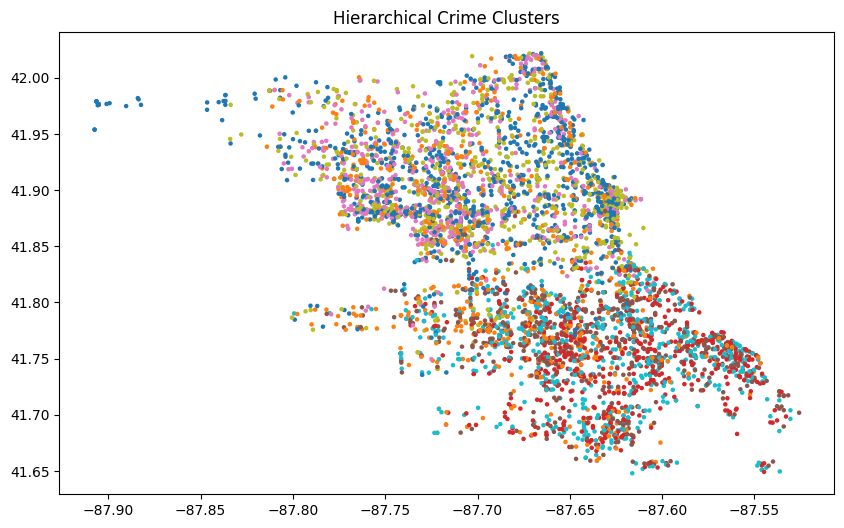

In [24]:
# Visualize Hierarchical Clusters

plt.figure(figsize=(10,6))

plt.scatter(

    hier_sample['Longitude'],

    hier_sample['Latitude'],

    c=hier_sample['HC_Cluster'],

    cmap='tab10',

    s=5
)

plt.title(
    'Hierarchical Crime Clusters'
)

plt.show()

In [25]:
# TEMPORAL CLUSTERING

# Encode Day

le_day = LabelEncoder()

df['Day_Encoded'] = (
    le_day.fit_transform(
        df['Day_of_Week']
    )
)

In [26]:
# Encode Season
le_season = LabelEncoder()

df['Season_Encoded'] = (

    le_season.fit_transform(
        df['Season']
    )
)

In [27]:
# Temporal Features

temp_features = [

    'Hour',

    'Day_Encoded',

    'Month',

    'Season_Encoded'
]

In [28]:
# Create Temporal Dataset

temp_df = df[temp_features].copy()

temp_df.dropna(inplace=True)

In [29]:
# Scale Temporal Data

scaler_temp = StandardScaler()

X_temp_scaled = scaler_temp.fit_transform(
    temp_df
)

In [30]:
# Train Temporal KMeans

kmeans_temp = KMeans(
    n_clusters=5,
    random_state=42
)

temp_df['Temporal_Cluster'] = (

    kmeans_temp.fit_predict(
        X_temp_scaled
    )
)

In [31]:
# Temporal Silhouette Score
temp_silhouette = silhouette_score(

    X_temp_scaled,

    temp_df['Temporal_Cluster'],

    sample_size=10000,

    random_state=42
)

print(
    "Temporal Silhouette Score :",
    temp_silhouette
)

Temporal Silhouette Score : 0.28007566458156274


C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


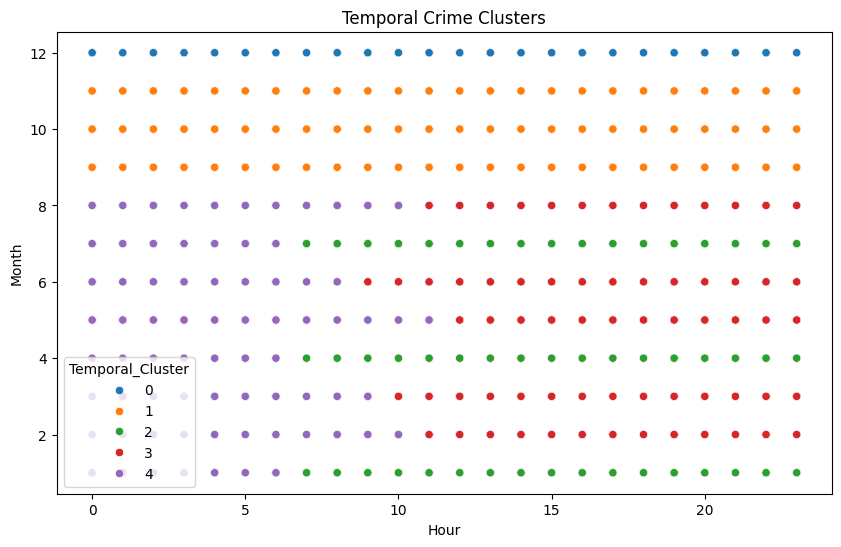

In [32]:
# Visualize Temporal Clusters

plt.figure(figsize=(10,6))

sns.scatterplot(

    x=temp_df['Hour'],

    y=temp_df['Month'],

    hue=temp_df['Temporal_Cluster'],

    palette='tab10'
)

plt.title('Temporal Crime Clusters')

plt.show()

In [33]:
# Create Comparison Table

comparison = pd.DataFrame({

    'Model': [

        'KMeans',

        'DBSCAN',

        'Hierarchical',

        'Temporal KMeans'
    ],

    'Silhouette Score': [

        geo_silhouette,

        silhouette_score(
            X_geo_sample,
            geo_sample['DBSCAN_Cluster'],
            sample_size=5000
        ),

        silhouette_score(
            X_hier,
            hier_sample['HC_Cluster']
        ),

        temp_silhouette
    ]
})

comparison

,Model,Silhouette Score
0,KMeans,0.175978
1,DBSCAN,-0.024947
2,Hierarchical,0.123284
3,Temporal KMeans,0.280076


In [34]:
# Save Geographic Clusters

geo_df.to_pickle(
    'geographic_clusters.pkl'
)